## Data pipeline with Keras and tf.data

### Instructions

In this notebook, I implement a data processing pipeline using tools from both Keras and the tf.data module. I will use the `ImageDataGenerator` class in the tf.keras module to feed a network with training and test images from a local directory containing a subset of the LSUN dataset, and train the model both with and without data augmentation. Afterwards, I use the `map` and `filter` functions of the `Dataset` class with the CIFAR-100 dataset to train a network to classify a processed subset of the images.

Some code cells are provided you in the notebook. You should avoid editing provided code, and make sure to execute the cells in order to avoid unexpected errors. Some cells begin with the line:

### Getting started!

Starts with running some imports, and loading the dataset.

In [17]:
#### PACKAGE IMPORTS ####

import tensorflow as tf
from tensorflow.keras.datasets import cifar100
import numpy as np
import matplotlib.pyplot as plt
import json
%matplotlib inline

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### Part 1: tf.keras
<table><tr>
<td> <img src="data/church.png" alt="Church" style="height: 210px;"/>  </td>
<td> <img src="data/classroom.png" alt="Classroom" style="height: 210px;"/> </td>
    <td> <img src="data/conference_room.png" alt="Conference Room" style="height: 210px;"/> </td>
</tr></table>
  
#### The LSUN Dataset

In the first part of this project, I use a subset of the [LSUN dataset](https://www.yf.io/p/lsun). This is a large-scale image dataset with 10 scene and 20 object categories. A subset of the LSUN dataset has been provided, and has already been split into training and test sets. The three classes included in the subset are `church_outdoor`, `classroom` and `conference_room`.

* F. Yu, A. Seff, Y. Zhang, S. Song, T. Funkhouser and J. Xia. "LSUN: Construction of a Large-scale Image Dataset using Deep Learning with Humans in the Loop". arXiv:1506.03365, 10 Jun 2015 

The goal is to use the Keras preprocessing tools to construct a data ingestion and augmentation pipeline to train a neural network to classify the images into the three classes.

In [3]:
# directory locations for the training, validation and test sets

train_dir = 'data/lsun/train'
valid_dir = 'data/lsun/valid'
test_dir = 'data/lsun/test'

#### Create a data generator using the ImageDataGenerator class

I create a function that creates an `ImageDataGenerator` object, which rescales the image pixel values by a factor of 1/255.

In [4]:
def get_ImageDataGenerator():
    """
    creates an instance of the ImageDataGenerator class.
    This instance should rescale the data with the above scaling factor.
    """
    image_data_gen = ImageDataGenerator(rescale=1/255.)
    return image_data_gen

In [5]:
# Call the function to get an ImageDataGenerator

image_gen = get_ImageDataGenerator()

I write a function that returns a generator object that will yield batches of images and labels from the training and test set directories. The generators should:

* Generate batches of size 20.
* Resize the images to 64 x 64 x 3.
* Return one-hot vectors for labels. These should be encoded as follows:
    * `classroom` $\rightarrow$ `[1., 0., 0.]`
    * `conference_room` $\rightarrow$ `[0., 1., 0.]`
    * `church_outdoor` $\rightarrow$ `[0., 0., 1.]`
* Pass in an optional random `seed` for shuffling (this should be passed into the `flow_from_directory` method).

In [206]:
def get_generator(image_data_generator, directory, seed=None):
    """
    Takes an ImageDataGenerator object in the first argument and a 
    directory path in the second argument.
    It returns the ImageDataGenerator as a generator object according 
    to the above specifications. 
    The seed argument should be passed to the flow_from_directory method.
    """
    image_data_gen = image_data_generator.flow_from_directory(
        directory,
        batch_size=20,
        target_size=(64, 64),
        class_mode="categorical",
        seed=seed
    )
    return image_data_gen
    

In [207]:
# Run this cell to define training and validation generators

train_generator = get_generator(image_gen, train_dir)
valid_generator = get_generator(image_gen, valid_dir)

Found 300 images belonging to 3 classes.
Found 120 images belonging to 3 classes.


A small subset of the dataset for demonstrative purposes.

#### Display sample images and labels from the training set

The following cell depends on the function `get_generator` to be implemented correctly.

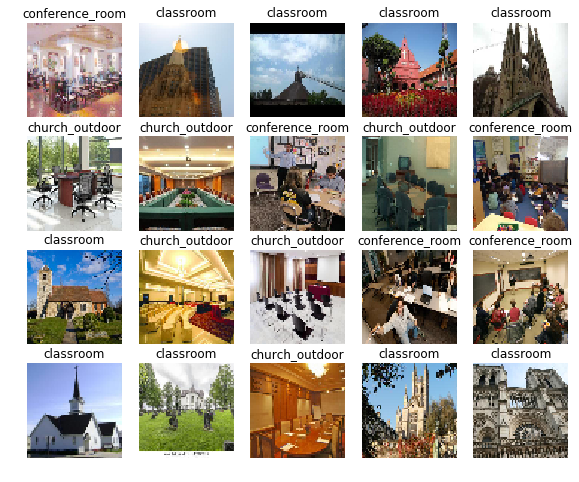

In [8]:
# Display a few images and labels from the training set

batch = next(train_generator)
batch_images = np.array(batch[0])
batch_labels = np.array(batch[1])
lsun_classes = ['classroom', 'conference_room', 'church_outdoor']

plt.figure(figsize=(10, 8))

for i in range(20):
    ax = plt.subplot(4, 5, i+1)
    plt.imshow(batch_images[i])
    plt.title(lsun_classes[np.where(batch_labels[i] == 1.)[0][0]])
    plt.axis('off')
    
plt.subplots_adjust(wspace=0.001)

In [9]:
# Reset the training generator

train_generator = get_generator(image_gen, train_dir)

Found 300 images belonging to 3 classes.


#### Build the neural network model

I build and compile a convolutional neural network classifier using the functional API according to the following specifications:

* The model should use the `input_shape` in the function argument to define the Input layer.
* The first hidden layer should be a Conv2D layer with 8 filters, a 8x8 kernel size.
* The second hidden layer should be a MaxPooling2D layer with a 2x2 pooling window size.
* The third hidden layer should be a Conv2D layer with 4 filters, a 4x4 kernel size.
* The fourth hidden layer should be a MaxPooling2D layer with a 2x2 pooling window size.
* This should be followed by a Flatten layer, and then a Dense layer with 16 units and ReLU activation.
* The final layer should be a Dense layer with 3 units and softmax activation.
* All Conv2D layers should use `"SAME"` padding and a ReLU activation function.

In total, the network has 8 layers. The model should then be compiled with the Adam optimizer with learning rate 0.0005, categorical cross entropy loss, and the 'accuracy' metric.

In [10]:
def get_model(input_shape):
    """
    Build and compile a CNN model according to the above specification,
    using the functional API.
    
    Returns:
    Functional API model
    """
    input_data = tf.keras.layers.Input(input_shape)
    x = tf.keras.layers.Conv2D(8, 8, activation='relu', padding='same')(input_data)
    x = tf.keras.layers.MaxPooling2D(2)(x)
    x = tf.keras.layers.Conv2D(4, 4, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(16, activation='relu')(x)
    output_data = tf.keras.layers.Dense(3, activation='softmax')(x)
    
    model = tf.keras.models.Model(input_data, output_data)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr=0.0005), loss='categorical_crossentropy', metrics=['accuracy']
    )
    return model

In [11]:
# Build and compile the model, print the model summary

lsun_model = get_model((64, 64, 3))
lsun_model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 64, 64, 3)]       0         
_________________________________________________________________
conv2d (Conv2D)              (None, 64, 64, 8)         1544      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 32, 32, 8)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 32, 32, 4)         516       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 16, 16, 4)         0         
_________________________________________________________________
flatten (Flatten)            (None, 1024)              0         
_________________________________________________________________
dense (Dense)                (None, 16)                16400 

#### Train the neural network model
I write a function to train the model for a specified number of epochs (specified in the `epochs` argument). The function takes a `model` argument, as well as `train_gen` and `valid_gen` arguments for the training and validation generators respectively, use for training and validation data in the training run. Also use the defined callbacks:

* An `EarlyStopping` callback that monitors the validation accuracy and has patience set to 10. 
* A `ReduceLROnPlateau` callback that monitors the validation loss and has the factor set to 0.5 and minimum learning set to 0.0001

The helper function returns the training history.

In [12]:
def train_model(model, train_gen, valid_gen, epochs):
    """
    Define the callback objects and then use the
    train_gen and valid_gen generator object arguments to train the model for the (maximum) 
    number of epochs specified in the function argument, using the defined callbacks.
    The function returns the training history.
    """
    early_stop = EarlyStopping(monitor='val_accuracy', patience=10)
    lr_reducer = ReduceLROnPlateau(monitor="val_loss", factor=0.5, min_lr=0.0001)
    
    history = model.fit(
        train_gen,
        validation_data=valid_gen,
        epochs=epochs,
        callbacks=[early_stop, lr_reducer],
        verbose=2)
    return history

In [13]:
# Train the model for (maximum) 50 epochs

history = train_model(lsun_model, train_generator, valid_generator, epochs=50)

Train for 15 steps, validate for 6 steps
Epoch 1/50
15/15 - 12s - loss: 1.1334 - accuracy: 0.3033 - val_loss: 1.0943 - val_accuracy: 0.3333
Epoch 2/50
15/15 - 9s - loss: 1.0930 - accuracy: 0.3700 - val_loss: 1.0868 - val_accuracy: 0.3750
Epoch 3/50
15/15 - 9s - loss: 1.0824 - accuracy: 0.4300 - val_loss: 1.0786 - val_accuracy: 0.3833
Epoch 4/50
15/15 - 9s - loss: 1.0595 - accuracy: 0.4967 - val_loss: 1.0621 - val_accuracy: 0.4833
Epoch 5/50
15/15 - 9s - loss: 1.0256 - accuracy: 0.5233 - val_loss: 1.0464 - val_accuracy: 0.4417
Epoch 6/50
15/15 - 9s - loss: 0.9938 - accuracy: 0.4700 - val_loss: 1.0782 - val_accuracy: 0.4500
Epoch 7/50
15/15 - 9s - loss: 0.9651 - accuracy: 0.5800 - val_loss: 1.0253 - val_accuracy: 0.4500
Epoch 8/50
15/15 - 9s - loss: 0.9259 - accuracy: 0.5933 - val_loss: 0.9556 - val_accuracy: 0.5333
Epoch 9/50
15/15 - 9s - loss: 0.8431 - accuracy: 0.6500 - val_loss: 0.9336 - val_accuracy: 0.5583
Epoch 10/50
15/15 - 9s - loss: 0.8103 - accuracy: 0.6500 - val_loss: 0.9497 

#### Plot the learning curves

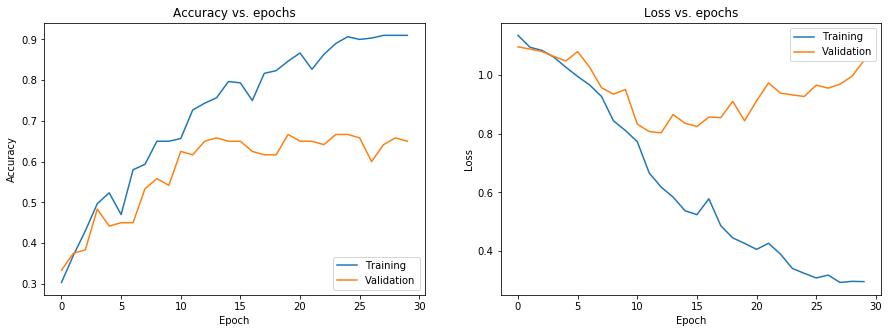

In [14]:
# Run this cell to plot accuracy vs epoch and loss vs epoch

plt.figure(figsize=(15, 5))
plt.subplot(121)
try:
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
except KeyError:
    try:
        plt.plot(history.history['acc'])
        plt.plot(history.history['val_acc'])
    except KeyError:
        plt.plot(history.history['categorical_accuracy'])
        plt.plot(history.history['val_categorical_accuracy'])

plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')

plt.subplot(122)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

There is an overfitting in the above plots, through a growing discrepancy between the training and validation loss and accuracy. I aim to mitigate this issue using data augmentation. Given the limited dataset, I might improve the performance of the network by applying random modifications to the images in the training data, effectively increasing the size of the dataset.

#### Create a new data generator with data augmentation

I write a function to create a new `ImageDataGenerator` object, which performs the following data preprocessing and augmentation:

* Scales the image pixel values by a factor of 1/255.
* Randomly rotates images by up to 30 degrees
* Randomly alters the brightness (picks a brightness shift value) from the range (0.5, 1.5)
* Randomly flips images horizontally

In [15]:
def get_ImageDataGenerator_augmented():
    """
    Return an instance of the ImageDataGenerator class.
    """
    image_data_gen = ImageDataGenerator(
        rescale=1/255.,
        brightness_range=(0.5, 1.5),
        rotation_range=30,
        horizontal_flip=True
    )
    return image_data_gen

In [18]:
# Call the function to get an ImageDataGenerator

image_gen_aug = get_ImageDataGenerator_augmented()

In [19]:
# Run this cell to define training and validation generators 

valid_generator_aug = get_generator(image_gen_aug, valid_dir)
train_generator_aug = get_generator(image_gen_aug, train_dir, seed=10)

Found 120 images belonging to 3 classes.
Found 300 images belonging to 3 classes.


In [20]:
# Reset the original train_generator with the same random seed

train_generator = get_generator(image_gen, train_dir, seed=10)

Found 300 images belonging to 3 classes.


#### Display sample augmented images and labels from the training set

The following cell depends on the function `get_generator` to be implemented correctly.
The cell will display augmented and non-augmented images (and labels) from the training dataset, using the `train_generator_aug` and `train_generator` objects defined above.

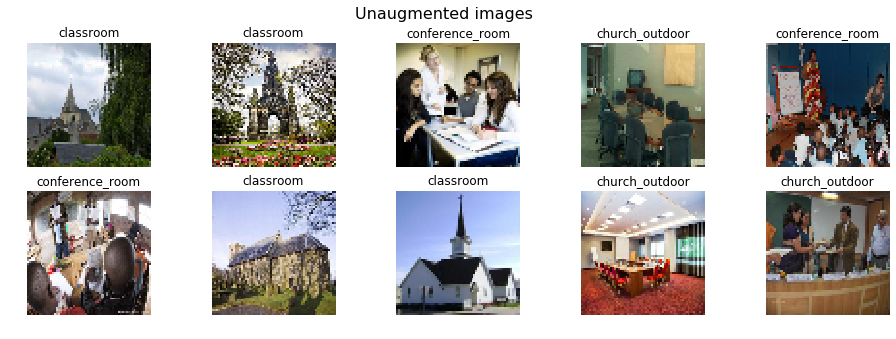

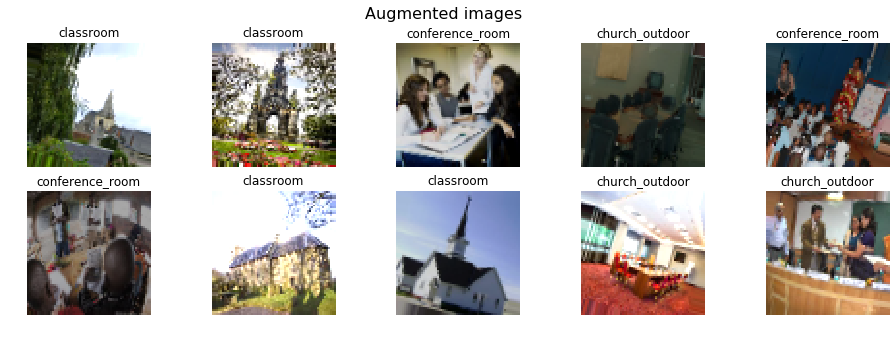

In [21]:
# Display a few images and labels from the non-augmented and augmented generators

batch = next(train_generator)
batch_images = np.array(batch[0])
batch_labels = np.array(batch[1])

aug_batch = next(train_generator_aug)
aug_batch_images = np.array(aug_batch[0])
aug_batch_labels = np.array(aug_batch[1])

plt.figure(figsize=(16, 5))
plt.suptitle("Unaugmented images", fontsize=16)
for n, i in enumerate(np.arange(10)):
    ax = plt.subplot(2, 5, n+1)
    plt.imshow(batch_images[i])
    plt.title(lsun_classes[np.where(batch_labels[i] == 1.)[0][0]])
    plt.axis('off')
plt.figure(figsize=(16,5))
plt.suptitle("Augmented images", fontsize=16)
for n, i in enumerate(np.arange(10)):
    ax = plt.subplot(2, 5, n+1)
    plt.imshow(aug_batch_images[i])
    plt.title(lsun_classes[np.where(aug_batch_labels[i] == 1.)[0][0]])
    plt.axis('off')

In [22]:
# Reset the augmented data generator

train_generator_aug = get_generator(image_gen_aug, train_dir)

Found 300 images belonging to 3 classes.


#### Train a new model on the augmented dataset

In [23]:
# Build and compile a new model

lsun_new_model = get_model((64, 64, 3))

In [24]:
# Train the model

history_augmented = train_model(lsun_new_model, train_generator_aug, valid_generator_aug, epochs=50)

Train for 15 steps, validate for 6 steps
Epoch 1/50
15/15 - 12s - loss: 1.1063 - accuracy: 0.3800 - val_loss: 1.0849 - val_accuracy: 0.4083
Epoch 2/50
15/15 - 11s - loss: 1.0548 - accuracy: 0.4400 - val_loss: 1.0142 - val_accuracy: 0.4917
Epoch 3/50
15/15 - 11s - loss: 1.0053 - accuracy: 0.5500 - val_loss: 0.9381 - val_accuracy: 0.5917
Epoch 4/50
15/15 - 10s - loss: 0.9024 - accuracy: 0.6133 - val_loss: 0.8860 - val_accuracy: 0.5750
Epoch 5/50
15/15 - 11s - loss: 0.8347 - accuracy: 0.6467 - val_loss: 0.7808 - val_accuracy: 0.6500
Epoch 6/50
15/15 - 11s - loss: 0.7995 - accuracy: 0.6433 - val_loss: 0.8413 - val_accuracy: 0.6250
Epoch 7/50
15/15 - 11s - loss: 0.7583 - accuracy: 0.6400 - val_loss: 0.8287 - val_accuracy: 0.6333
Epoch 8/50
15/15 - 11s - loss: 0.7361 - accuracy: 0.6733 - val_loss: 0.7517 - val_accuracy: 0.6667
Epoch 9/50
15/15 - 11s - loss: 0.7088 - accuracy: 0.6733 - val_loss: 0.7740 - val_accuracy: 0.6583
Epoch 10/50
15/15 - 11s - loss: 0.7032 - accuracy: 0.6900 - val_loss

#### Plot the learning curves

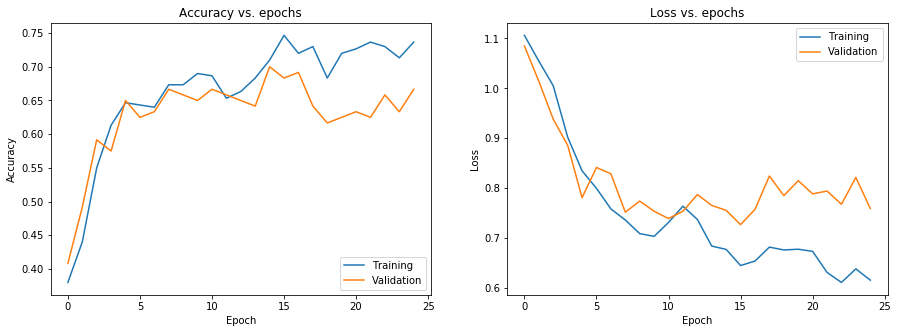

In [25]:
# Run this cell to plot accuracy vs epoch and loss vs epoch

plt.figure(figsize=(15,5))
plt.subplot(121)
try:
    plt.plot(history_augmented.history['accuracy'])
    plt.plot(history_augmented.history['val_accuracy'])
except KeyError:
    try:
        plt.plot(history_augmented.history['acc'])
        plt.plot(history_augmented.history['val_acc'])
    except KeyError:
        plt.plot(history_augmented.history['categorical_accuracy'])
        plt.plot(history_augmented.history['val_categorical_accuracy'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')

plt.subplot(122)
plt.plot(history_augmented.history['loss'])
plt.plot(history_augmented.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

There was an improvement in the overfitting. This will, of course vary based on a particular run and the hyperparameters that have been altered.

#### Get predictions using the trained model

In [26]:
# Get model predictions for the first 3 batches of test data

num_batches = 3
seed = 25
test_generator = get_generator(image_gen_aug, test_dir, seed=seed)
predictions = lsun_new_model.predict_generator(test_generator, steps=num_batches)

Found 300 images belonging to 3 classes.


Found 300 images belonging to 3 classes.
[26 14 27 55]


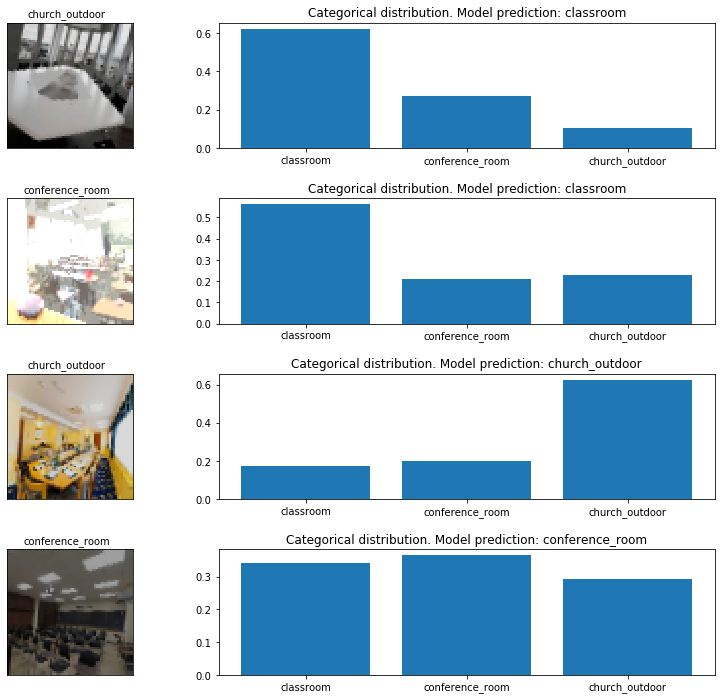

In [27]:
# Run this cell to view randomly selected images and model predictions

# Get images and ground truth labels
test_generator = get_generator(image_gen_aug, test_dir, seed=seed)
batches = []
for i in range(num_batches):
    batches.append(next(test_generator))
    
batch_images = np.vstack([b[0] for b in batches])
batch_labels = np.concatenate([b[1].astype(np.int32) for b in batches])

# Randomly select images from the batch
inx = np.random.choice(predictions.shape[0], 4, replace=False)
print(inx)

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
fig.subplots_adjust(hspace=0.4, wspace=-0.2)

for n, i in enumerate(inx):
    axes[n, 0].imshow(batch_images[i])
    axes[n, 0].get_xaxis().set_visible(False)
    axes[n, 0].get_yaxis().set_visible(False)
    axes[n, 0].text(30., -3.5, lsun_classes[np.where(batch_labels[i] == 1.)[0][0]], 
                    horizontalalignment='center')
    axes[n, 1].bar(np.arange(len(predictions[i])), predictions[i])
    axes[n, 1].set_xticks(np.arange(len(predictions[i])))
    axes[n, 1].set_xticklabels(lsun_classes)
    axes[n, 1].set_title(f"Categorical distribution. Model prediction: {lsun_classes[np.argmax(predictions[i])]}")
    
plt.show()

This completes the first part of the task using the tf.keras image data processing tools.

### Part 2: tf.data

![CIFAR-100 overview image](data/cifar100/cifar100.png)

#### The CIFAR-100 Dataset

In the second part of this assignment, I will use the [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html). This image dataset has 100 classes with 500 training images and 100 test images per class. 

* A. Krizhevsky. "Learning Multiple Layers of Features from Tiny Images". April 2009 

The goal is to use the tf.data module preprocessing tools to construct a data ingestion pipeline including filtering and function mapping over the dataset to train a neural network to classify the images.

#### Load the dataset

In [182]:
# Load the data, along with the labels

(train_data, train_labels), (test_data, test_labels) = cifar100.load_data(label_mode='fine')
with open('data/cifar100/cifar100_labels.json', 'r') as j:
    cifar_labels = json.load(j)

#### Display sample images and labels from the training set

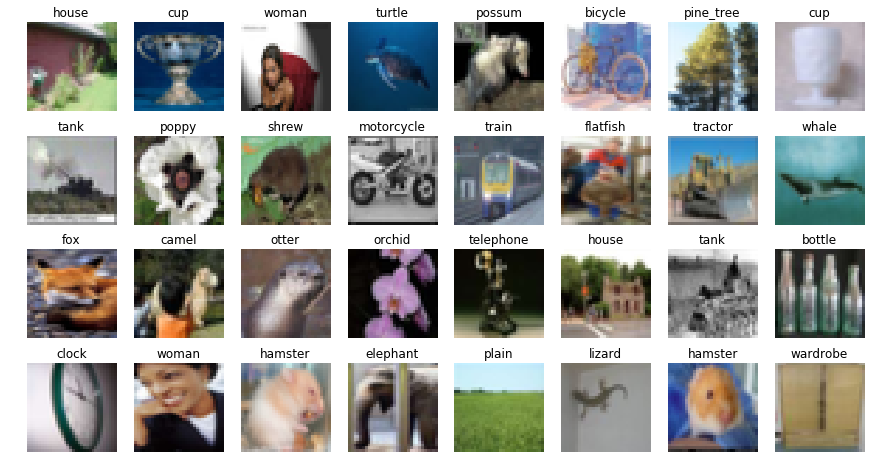

In [183]:
# Display a few images and labels

plt.figure(figsize=(15, 8))
inx = np.random.choice(train_data.shape[0], 32, replace=False)
for n, i in enumerate(inx):
    ax = plt.subplot(4, 8, n+1)
    plt.imshow(train_data[i])
    plt.title(cifar_labels[int(train_labels[i])])
    plt.axis('off')

#### Create Dataset objects for the train and test images

I write a function to create a `tf.data.Dataset` object for each of the training and test images and labels. This function takes a numpy array of images in the first argument and a numpy array of labels in the second argument, and create a `Dataset` object. 

The function return the `Dataset` object.

In [184]:
def create_dataset(data, labels):
    """
    This function takes a numpy array batch of images in the first argument, and
    a corresponding array containing the labels in the second argument.
    Then creates a tf.data.Dataset object with these inputs
    and outputs and return it.
    """
    return tf.data.Dataset.from_tensor_slices((data, labels))

In [185]:
# Run the below cell to convert the training and test data and labels into datasets

train_dataset = create_dataset(train_data, train_labels)
test_dataset = create_dataset(test_data, test_labels)

In [186]:
# Check the element_spec of your datasets

print(train_dataset.element_spec)
print(test_dataset.element_spec)

(TensorSpec(shape=(32, 32, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(1,), dtype=tf.int64, name=None))
(TensorSpec(shape=(32, 32, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(1,), dtype=tf.int64, name=None))


#### Filter the Dataset

I write a function to filter the train and test datasets so that they only generate images that belong to a specified set of classes. 

The function take a `Dataset` object in the first argument and a list of integer class indices in the second argument. Inside the function I define another function that will use with the `filter` method of the `Dataset` object. This nested function should take image and label arguments (as in the `element_spec`) for a single element in the batch, and return a boolean indicating if the label is one of the allowed classes. 

Your function should then return the filtered dataset.

In [187]:
def filter_classes(dataset, classes):
    """
    This function filter the dataset by only retaining dataset elements whose
    label belongs to one of the integers in the classes list.
    The function should then return the filtered Dataset object.
    """
    def is_allowed(data, labels):
        allowed = tf.cast(classes, labels.dtype)
        matches = tf.equal(labels, classes)
        return tf.math.reduce_any(matches)
    
    return dataset.filter(is_allowed)

In [188]:
# Run the below cell to filter the datasets using your function

cifar_classes = [0, 29, 99] # the dataset contains only classes in this list; 0 = apple, 29=worm, 99=dinosaur

train_dataset = filter_classes(train_dataset, cifar_classes)
test_dataset = filter_classes(test_dataset, cifar_classes)

#### Apply map functions to the Dataset

I write two functions that use the `map` method to process the images and labels in the filtered dataset. 

The first function one-hot encode the remaining labels so that we can train the network using a categorical cross entropy loss. 

The function takea a `Dataset` object as an argument. Inside the function, I define an another function that will use the `map` method of the `Dataset` object. This nested function takes image and label as arguments (as in the `element_spec`) for a single element in the batch, and return a tuple of two elements, with the unmodified image in the first element, and a one-hot vector in the second element. The labels are encoded according to the following:

* Class 0 maps to `[1., 0., 0.]`
* Class 29 maps to `[0., 1., 0.]`
* Class 99 maps to `[0., 0., 1.]`

Your function returns the mapped dataset.

In [189]:
def map_labels(dataset):
    """
    This function map over the dataset to convert the label to a 
    one-hot vector. The encoding was done according to the above specification.
    The function returns the mapped Dataset object.
    """
    def one_hot_encoding(data, labels):
        one_hot_labels = tf.cast(tf.equal(labels, tf.constant([0, 29, 99], dtype=tf.int64)), tf.float32)
        return data, one_hot_labels
    
    return dataset.map(one_hot_encoding)
    

In [190]:
# Run the below cell to one-hot encode the training and test labels.

train_dataset = map_labels(train_dataset)
test_dataset = map_labels(test_dataset)

The second function process the images according to the following specification:

* Rescale the image pixel values by a factor of 1/255.
* Convert the colour images (3 channels) to black and white images (single channel) by computing the average pixel value across all channels. 

The function takes a `Dataset` object as an argument. Inside the function, I again define an another function that will use with the `map` method of the `Dataset` object. This nested function takes image and label as arguments (as in the `element_spec`) for a single element in the batch, and return a tuple of two elements, with the processed image in the first element, and the unmodified label in the second argument.

Your function returns the mapped dataset.

In [191]:
def map_images(dataset):
    """
    This function map over the dataset to process the image according to the 
    above specification. The function returns the mapped Dataset object.
    """
    def rescale_and_transform(data, labels):
        rescaled_images = tf.cast(data, tf.float32) / 255.
        transformed_images = tf.reduce_mean(rescaled_images, axis=-1, keepdims=True)
        return transformed_images, labels
    
    return dataset.map(rescale_and_transform)
    

In [192]:
# Run the below cell to apply your mapping function to the datasets

train_dataset_bw = map_images(train_dataset)
test_dataset_bw = map_images(test_dataset)

#### Display a batch of processed images

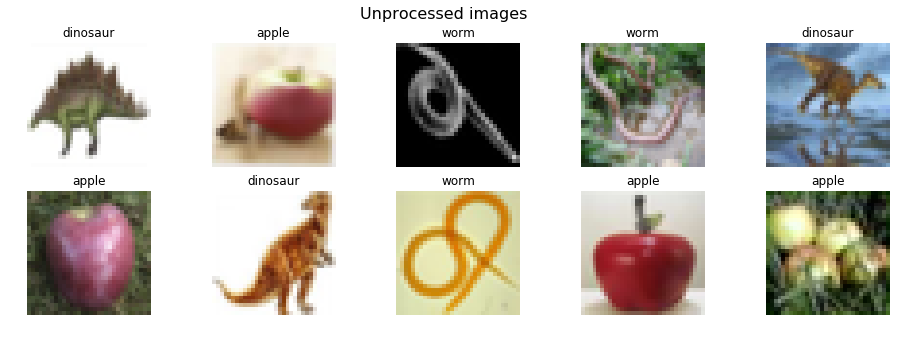

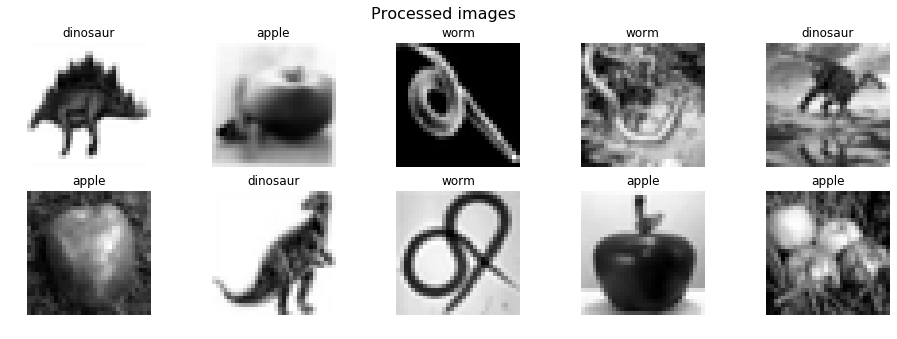

In [193]:
# Run this cell to view a selection of images before and after processing

plt.figure(figsize=(16, 5))
plt.suptitle("Unprocessed images", fontsize=16)
for n, elem in enumerate(train_dataset.take(10)):
    images, labels = elem
    ax = plt.subplot(2, 5, n+1)
    plt.title(cifar_labels[cifar_classes[np.where(labels == 1.)[0][0]]])
    plt.imshow(np.squeeze(images), cmap='gray')
    plt.axis('off')
    
plt.figure(figsize=(16,5))
plt.suptitle("Processed images", fontsize=16)
for n, elem in enumerate(train_dataset_bw.take(10)):
    images_bw, labels_bw = elem
    ax = plt.subplot(2, 5, n+1)
    plt.title(cifar_labels[cifar_classes[np.where(labels_bw == 1.)[0][0]]])
    plt.imshow(np.squeeze(images_bw), cmap='gray')
    plt.axis('off')

Now, I batch and shuffle the Dataset objects.

In [194]:
# Run the below cell to batch the training dataset and expand the final dimensinos

train_dataset_bw = train_dataset_bw.batch(10)
train_dataset_bw = train_dataset_bw.shuffle(100)

test_dataset_bw = test_dataset_bw.batch(10)
test_dataset_bw = test_dataset_bw.shuffle(100)

#### Train a neural network model

Now I train a model using the `Dataset` objects. I use the model specification and function from the first part of this task, only modifying the size of the input images.

In [195]:
# Build and compile a new model with our original spec, using the new image size
    
cifar_model = get_model((32, 32, 1))

In [196]:
# Train the model for 15 epochs

history = cifar_model.fit(train_dataset_bw, validation_data=test_dataset_bw, epochs=15)

Epoch 1/15
150/150 [==============================] - 21s 143ms/step - loss: 1.0363 - accuracy: 0.4280 - val_loss: 0.0000e+00 - val_accuracy: 0.0000e+00
Epoch 2/15
150/150 [==============================] - 19s 129ms/step - loss: 0.8646 - accuracy: 0.6020 - val_loss: 0.7688 - val_accuracy: 0.6767
Epoch 3/15
150/150 [==============================] - 20s 130ms/step - loss: 0.7401 - accuracy: 0.6760 - val_loss: 0.6947 - val_accuracy: 0.7433
Epoch 4/15
150/150 [==============================] - 19s 127ms/step - loss: 0.6786 - accuracy: 0.7147 - val_loss: 0.6672 - val_accuracy: 0.7667
Epoch 5/15
150/150 [==============================] - 19s 128ms/step - loss: 0.6418 - accuracy: 0.7473 - val_loss: 0.6717 - val_accuracy: 0.7533
Epoch 6/15
150/150 [==============================] - 19s 130ms/step - loss: 0.6014 - accuracy: 0.7593 - val_loss: 0.7422 - val_accuracy: 0.6500
Epoch 7/15
150/150 [==============================] - 19s 127ms/step - loss: 0.5892 - accuracy: 0.7693 - val_loss: 0.6062 

#### Plot the learning curves

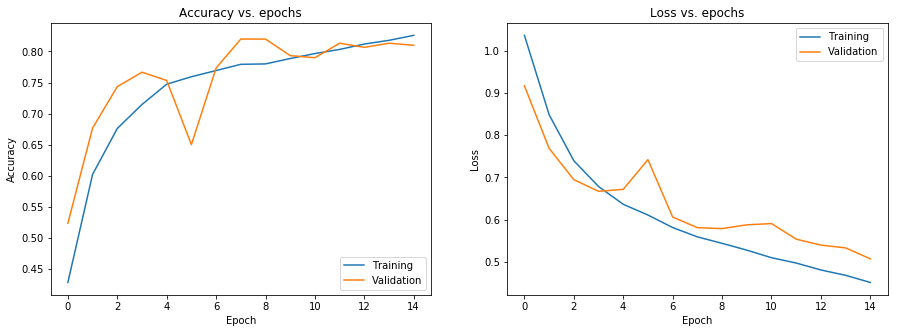

In [197]:
# Run this cell to plot accuracy vs epoch and loss vs epoch

plt.figure(figsize=(15,5))
plt.subplot(121)
try:
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
except KeyError:
    try:
        plt.plot(history.history['acc'])
        plt.plot(history.history['val_acc'])
    except KeyError:
        plt.plot(history.history['categorical_accuracy'])
        plt.plot(history.history['val_categorical_accuracy'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')

plt.subplot(122)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

In [198]:
# Create an iterable from the batched test dataset

test_dataset = test_dataset.batch(10)
iter_test_dataset = iter(test_dataset)

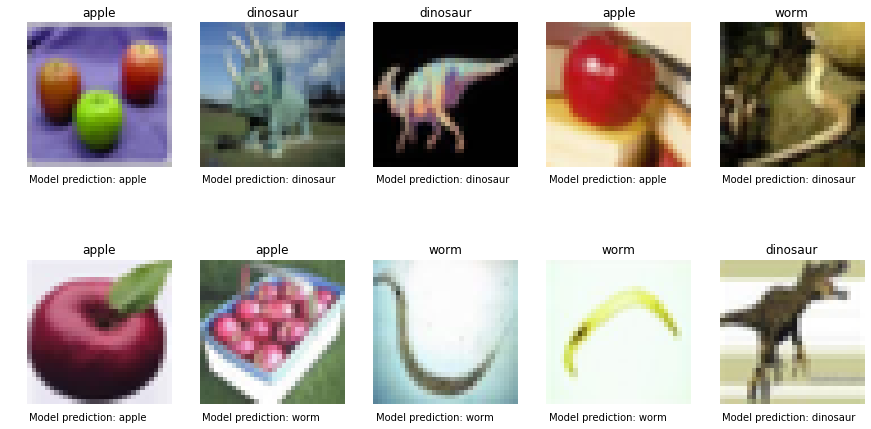

In [199]:
# Display model predictions for a sample of test images

plt.figure(figsize=(15, 8))
inx = np.random.choice(test_data.shape[0], 18, replace=False)
images, labels = next(iter_test_dataset)
probs = cifar_model(tf.reduce_mean(tf.cast(images, tf.float32), axis=-1, keepdims=True) / 255.)
preds = np.argmax(probs, axis=1)
for n in range(10):
    ax = plt.subplot(2, 5, n+1)
    plt.imshow(images[n])
    plt.title(cifar_labels[cifar_classes[np.where(labels[n].numpy() == 1.0)[0][0]]])
    plt.text(0, 35, "Model prediction: {}".format(cifar_labels[cifar_classes[preds[n]]]))
    plt.axis('off')